In [1]:
!git clone https://github.com/anthropics/jacobian-lens.git
%cd jacobian-lens
!pip install -e . -q
!pip install transformers accelerate bitsandbytes -q

Cloning into 'jacobian-lens'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 67 (delta 0), reused 0 (delta 0), pack-reused 65 (from 2)
Receiving objects: 100% (67/67), 1.90 MiB | 4.76 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/jacobian-lens
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jlens (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 21.3 MB/s eta 0:00:00


In [2]:
import jlens

jlens.configure_logging()

MODEL_NAME = "Qwen/Qwen3.5-4B"
# MODEL_NAME = "Qwen/Qwen3.6-27B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

MODEL_NAME = "Qwen/Qwen3.5-4B"

hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)
model

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)

In [4]:
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
lens

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))

In [8]:
import json
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

exp_dir = Path("data/experiments")

def load_prompts_from_json(json_path, max_prompts=12):
    with open(json_path) as f:
        data = json.load(f)

    items = data.get("items", data) if isinstance(data, dict) else data
    prompts = []

    for item in items:
        if not isinstance(item, dict):
            continue
        p = item.get("prompt")
        if p is None:
            continue
        # Handle multi-turn format
        if isinstance(p, list):
            p = "\n".join([m.get("content", str(m)) for m in p if isinstance(m, dict)])
        if isinstance(p, str) and len(p.strip()) > 10:
            prompts.append(p.strip())
        if len(prompts) >= max_prompts:
            break
    return prompts

prompts = load_prompts_from_json(exp_dir / "probe-swap.json", max_prompts=10)

# custom_prompts = [
#     "Fact: The largest planet in our solar system is",
#     "The nurse walked into the room and said hello. Then",
#     "The animal that says meow is a",
# ]
# prompts = custom_prompts + prompts

print(f"Total prompts to process: {len(prompts)}")
for i, p in enumerate(prompts[:3]):
    print(f"\n--- Prompt {i} ---\n{p[:200]}...")

Total prompts to process: 10

--- Prompt 0 ---
Fact: The language spoken in the country where the Amazon River ends is...

--- Prompt 1 ---
Fact: The hard covering on the back of the slow reptile that can pull its head inside its body is called a...

--- Prompt 2 ---
Fact: The number of legs on the large horned animal that roamed the American plains in huge herds is...


In [9]:
results = []

for prompt_idx, prompt in enumerate(tqdm(prompts, desc="Prompts")):

    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    n_tokens = len(input_ids)

    positions = list(range(n_tokens))

    try:
        lens_logits, model_logits, _ = lens.apply(
            model,
            prompt,
            positions=positions
        )
    except Exception as e:
        print(f"Skipping prompt {prompt_idx} because of error: {e}")
        continue

    for layer, logits in sorted(lens_logits.items()):
        for pos in range(logits.shape[0]):
            topk = logits[pos].topk(5)
            top1_id = topk.indices[0].item()
            top1_token = tokenizer.decode([top1_id]).replace("\n", "\\n")

            results.append({
                "prompt_idx": prompt_idx,
                "prompt_preview": prompt[:80].replace("\n", " "),
                "layer": int(layer),
                "position": pos,
                "top1_token": top1_token,
                "top1_id": top1_id,
            })

df = pd.DataFrame(results)
print(f"Collected {len(df)} rows")
df.head()

Prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Collected 6076 rows


,prompt_idx,prompt_preview,layer,position,top1_token,top1_id
0,0,Fact: The language spoken in the country where...,0,0,اً,149798
1,0,Fact: The language spoken in the country where...,0,1,;,26
2,0,Fact: The language spoken in the country where...,0,2,部份,105814
3,0,Fact: The language spoken in the country where...,0,3,–,1317
4,0,Fact: The language spoken in the country where...,0,4,``,9609


In [18]:
df.loc[df['prompt_idx'] == 0, 'prompt_preview'].iloc[0]

'Fact: The language spoken in the country where the Amazon River ends is'

In [19]:
prompt_0 = df[df["prompt_idx"] == 0]

token_sheet = prompt_0.pivot(
    index="layer", columns="position", values="top1_token"
)

token_sheet.style.set_properties(
    **{"text-align": "center", "border": "1px solid #ddd", "padding": "6px"}
)

position,0,1,2,3,4,5,6,7,8,9,10,11,12,13
layer,,,,,,,,,,,,,,
0,اً,;,部份,–,``,"""",",",--,--,",","”,",\n,s,--
1,``,:,\n\n,--,``,...,\n\n,--,"\""",the,Amazon,．,</,--
2,اً,\n\n,<|endoftext|>,–,“.,",",",",""",",--,",",Amazon,�,s,.
3,,...,The,--,\n \n,"""",.,。。,\\,.,Amazon,River,\n,...
4,,____,‘,--,‘’,""".",.,。。,____,.,Amazon,‑,______,.
5,‑,...,",",–,......,""".",.,。。,____,.,Amazon,．,",",...
6,<|endoftext|>,,‘,--,spoken,the,.,\\,____,"\""",Amazon,\n,______,...
7,<|endoftext|>,,"\""",language,spoken,""".",.,__,____,____,Amazon,________,______,...
8,<|endoftext|>,,"\""",language,spoken,\n,___,__,____,____,Amazon,river,______,...


In [31]:
df.loc[df['prompt_idx'] == 9, 'prompt_preview'].iloc[0]

'Fact: The time of day when the bird that hoots and can turn its head almost all '

/tmp/ipykernel_1348/1925987169.py:39: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1348/1925987169.py:39: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1348/1925987169.py:39: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1348/1925987169.py:39: UserWarning: Glyph 39134 (\N{CJK UNIFIED IDEOGRAPH-98DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1348/1925987169.py:39: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


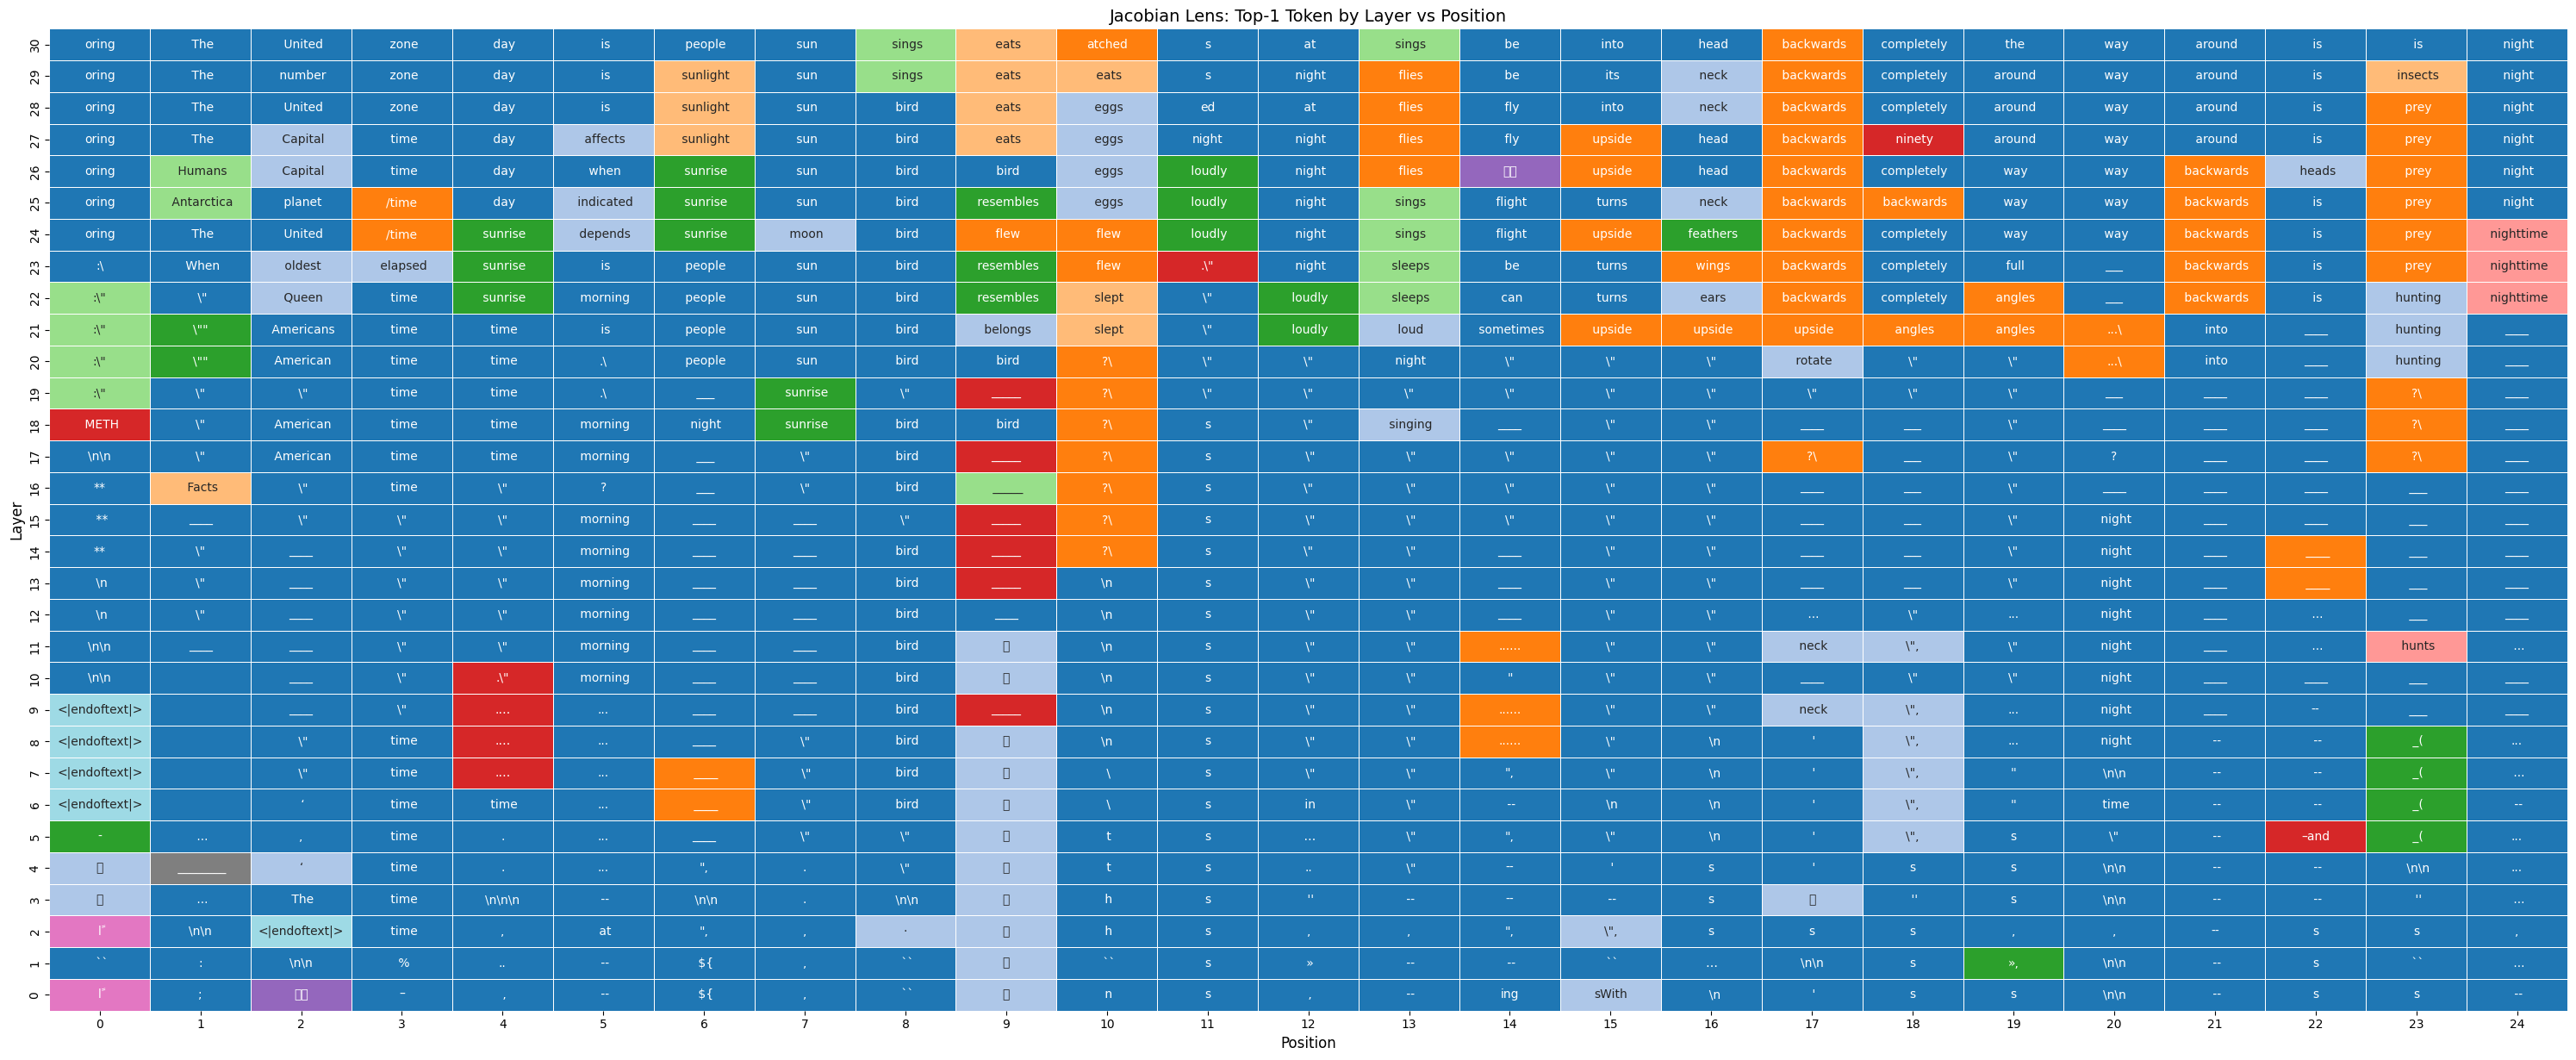

In [30]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

# Filter prompt
prompt_num = df[df["prompt_idx"] == 9]

token_grid = prompt_num.pivot(
    index="layer", columns="position", values="top1_token"
)
id_grid = prompt_num.pivot(index="layer", columns="position", values="top1_id")

# Plot
plt.figure(
    figsize=(
        max(10, len(token_grid.columns) * 1.2),
        max(6, len(token_grid.index) * 0.4),
    )
)
ax = sns.heatmap(
    id_grid,
    annot=token_grid,
    fmt="",
    cmap="tab20",
    cbar=False,
    linewidths=0.5,
    annot_kws={"size": 10},
)

plt.title("Jacobian Lens: Top-1 Token by Layer vs Position", fontsize=14)
plt.xlabel("Position", fontsize=12)
plt.ylabel("Layer", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# Basic per-layer summary
summary = (
    df.groupby("layer")
      .agg(
          n_observations=("top1_token", "count"),
          unique_top1_tokens=("top1_token", "nunique"),
          most_common_top1=("top1_token", lambda x: x.value_counts().index[0] if len(x) else None),
      )
      .reset_index()
      .sort_values("layer")
)

print(summary.to_string())

    layer  n_observations  unique_top1_tokens most_common_top1
0       0             196                  64               --
1       1             196                  48               ``
2       2             196                  65                ,
3       3             196                  65              ...
4       4             196                  68                .
5       5             196                  79              ...
6       6             196                  76               \"
7       7             196                  84               \"
8       8             196                  85               \"
9       9             196                  80             ____
10     10             196                  73             ____
11     11             196                  86             ____
12     12             196                  52             ____
13     13             196                  36             ____
14     14             196                  35          

In [21]:
# Save it
summary.to_csv("per_layer_summary.csv", index=False)
df.to_csv("all_lens_readouts.csv", index=False)
print("\nSaved per_layer_summary.csv and all_lens_readouts.csv")


Saved per_layer_summary.csv and all_lens_readouts.csv
